# Grab VN - Simple EDA Notebook

This notebook reads the SQLite database, applies basic formatting, and runs a few quick EDA summaries.

In [1]:
from pathlib import Path
import sqlite3

import pandas as pd
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 120)

In [2]:
DB_PATH = Path('grab_vn_case.db')
assert DB_PATH.exists(), f'Database not found: {DB_PATH.resolve()}'

conn = sqlite3.connect(DB_PATH)

users = pd.read_sql_query('SELECT * FROM users', conn)
weather_daily = pd.read_sql_query('SELECT * FROM weather_daily', conn)
transactions = pd.read_sql_query('SELECT * FROM transactions', conn)
daily_gmv_summary = pd.read_sql_query('SELECT * FROM daily_gmv_summary', conn)

conn.close()

print('Loaded tables:')
print('users:', users.shape)
print('weather_daily:', weather_daily.shape)
print('transactions:', transactions.shape)
print('daily_gmv_summary:', daily_gmv_summary.shape)

Loaded tables:
users: (11800, 5)
weather_daily: (294, 4)
transactions: (182313, 13)
daily_gmv_summary: (2642, 11)


In [3]:
# display head of each table
print('\nusers head:')
display(users.head())
print('\nweather_daily head:')
display(weather_daily.head())
print('\ntransactions head:')
display(transactions.head())
print('\ndaily_gmv_summary head:')
display(daily_gmv_summary.head())


users head:


,user_id,city,payment_preference,user_segment,registration_date
0,1,Ho Chi Minh City,Cash,Regular,2023-08-18
1,2,Ho Chi Minh City,ZaloPay,High Value,2023-08-03
2,3,Ho Chi Minh City,Cash,Voucher Hunter,2023-09-06
3,4,Ho Chi Minh City,Cash,Voucher Hunter,2023-07-25
4,5,Ho Chi Minh City,Cash,Regular,2022-07-29



weather_daily head:


,date,city,rainfall_mm,rain_category
0,2024-01-01,Ho Chi Minh City,1.6,None
1,2024-01-01,Da Nang,5.3,Light
2,2024-01-01,Hanoi,1.7,None
3,2024-01-02,Ho Chi Minh City,1.8,None
4,2024-01-02,Da Nang,5.3,Light



transactions head:


,transaction_id,date,week_number,period,city,service_type,user_id,payment_type,gross_gmv_k_vnd,discount_k_vnd,net_gmv_k_vnd,voucher_applied,rainfall_mm
0,1,2024-01-01,1,Pre-Promo,Ho Chi Minh City,GrabBike,2883,Card,35.53,0.0,35.53,0,1.6
1,2,2024-01-01,1,Pre-Promo,Ho Chi Minh City,GrabBike,5904,Cash,36.74,0.0,36.74,0,1.6
2,3,2024-01-01,1,Pre-Promo,Ho Chi Minh City,GrabBike,1193,Cash,44.65,0.0,44.65,0,1.6
3,4,2024-01-01,1,Pre-Promo,Ho Chi Minh City,GrabBike,3622,ZaloPay,38.32,0.0,38.32,0,1.6
4,5,2024-01-01,1,Pre-Promo,Ho Chi Minh City,GrabBike,5869,Cash,28.52,0.0,28.52,0,1.6



daily_gmv_summary head:


,date,week_number,period,city,service_type,payment_type,net_gmv_k_vnd,gross_gmv_k_vnd,total_discount_k_vnd,n_transactions,n_voucher_redemptions
0,2024-01-01,1,Pre-Promo,Da Nang,GrabBike,Card,332.00,332.00,0.0,9,0
1,2024-01-01,1,Pre-Promo,Da Nang,GrabBike,Cash,1832.92,1832.92,0.0,51,0
2,2024-01-01,1,Pre-Promo,Da Nang,GrabBike,ZaloPay,632.41,632.41,0.0,17,0
3,2024-01-01,1,Pre-Promo,Da Nang,GrabCar,Card,152.75,152.75,0.0,1,0
4,2024-01-01,1,Pre-Promo,Da Nang,GrabCar,Cash,1895.53,1895.53,0.0,14,0


In [4]:
# Basic formatting
users['registration_date'] = pd.to_datetime(users['registration_date'], errors='coerce')
weather_daily['date'] = pd.to_datetime(weather_daily['date'], errors='coerce')
transactions['date'] = pd.to_datetime(transactions['date'], errors='coerce')
daily_gmv_summary['date'] = pd.to_datetime(daily_gmv_summary['date'], errors='coerce')


daily_gmv_summary['net_gmv_m_vnd'] = daily_gmv_summary['net_gmv_k_vnd'] / 1000.0

quality = pd.DataFrame([
    {
        'table': 'users',
        'rows': len(users),
        'missing_cells': int(users.isna().sum().sum()),
        'duplicate_user_id': int(users['user_id'].duplicated().sum())
    },
    {
        'table': 'weather_daily',
        'rows': len(weather_daily),
        'missing_cells': int(weather_daily.isna().sum().sum()),
        'duplicate_user_id': None
    },
    {
        'table': 'transactions',
        'rows': len(transactions),
        'missing_cells': int(transactions.isna().sum().sum()),
        'duplicate_user_id': int(transactions['transaction_id'].duplicated().sum())
    },
    {
        'table': 'daily_gmv_summary',
        'rows': len(daily_gmv_summary),
        'missing_cells': int(daily_gmv_summary.isna().sum().sum()),
        'duplicate_user_id': None
    }
])

quality

,table,rows,missing_cells,duplicate_user_id
0,users,11800,0,0.0
1,weather_daily,294,0,NaN
2,transactions,182313,0,0.0
3,daily_gmv_summary,2642,0,NaN


In [5]:
# check if daily_gmv_summary is correct by comparing with transactions
group_by_cols = ['date','service_type','city','payment_type']
transactions['date'] = pd.to_datetime(transactions['date'])
gmv_summary_dummy = transactions.groupby(group_by_cols)['gross_gmv_k_vnd'].sum().reset_index()
gmv_summary_dummy.columns = group_by_cols + ['gmv_from_transactions']
gmv_comparison = pd.merge(daily_gmv_summary, gmv_summary_dummy, on=group_by_cols)
gmv_comparison['gmv_diff'] = gmv_comparison['gross_gmv_k_vnd'] - gmv_comparison['gmv_from_transactions']
print('\nGMV comparison:')
display(gmv_comparison.head())


GMV comparison:


,date,week_number,period,city,service_type,payment_type,net_gmv_k_vnd,gross_gmv_k_vnd,total_discount_k_vnd,n_transactions,n_voucher_redemptions,net_gmv_m_vnd,gmv_from_transactions,gmv_diff
0,2024-01-01,1,Pre-Promo,Da Nang,GrabBike,Card,332.00,332.00,0.0,9,0,0.33200,332.00,0.0
1,2024-01-01,1,Pre-Promo,Da Nang,GrabBike,Cash,1832.92,1832.92,0.0,51,0,1.83292,1832.92,0.0
2,2024-01-01,1,Pre-Promo,Da Nang,GrabBike,ZaloPay,632.41,632.41,0.0,17,0,0.63241,632.41,0.0
3,2024-01-01,1,Pre-Promo,Da Nang,GrabCar,Card,152.75,152.75,0.0,1,0,0.15275,152.75,0.0
4,2024-01-01,1,Pre-Promo,Da Nang,GrabCar,Cash,1895.53,1895.53,0.0,14,0,1.89553,1895.53,0.0


In [6]:
daily_gmv_summary

,date,week_number,period,city,service_type,payment_type,net_gmv_k_vnd,gross_gmv_k_vnd,total_discount_k_vnd,n_transactions,n_voucher_redemptions,net_gmv_m_vnd
0,2024-01-01,1,Pre-Promo,Da Nang,GrabBike,Card,332.00,332.00,0.0,9,0,0.33200
1,2024-01-01,1,Pre-Promo,Da Nang,GrabBike,Cash,1832.92,1832.92,0.0,51,0,1.83292
2,2024-01-01,1,Pre-Promo,Da Nang,GrabBike,ZaloPay,632.41,632.41,0.0,17,0,0.63241
3,2024-01-01,1,Pre-Promo,Da Nang,GrabCar,Card,152.75,152.75,0.0,1,0,0.15275
4,2024-01-01,1,Pre-Promo,Da Nang,GrabCar,Cash,1895.53,1895.53,0.0,14,0,1.89553
...,...,...,...,...,...,...,...,...,...,...,...,...
2637,2024-04-07,14,Post-Promo,Ho Chi Minh City,GrabCar,Cash,6902.77,6902.77,0.0,54,0,6.90277
2638,2024-04-07,14,Post-Promo,Ho Chi Minh City,GrabCar,ZaloPay,4528.40,4528.40,0.0,36,0,4.52840
2639,2024-04-07,14,Post-Promo,Ho Chi Minh City,GrabFood,Card,19849.06,19849.06,0.0,121,0,19.84906
2640,2024-04-07,14,Post-Promo,Ho Chi Minh City,GrabFood,Cash,50761.80,50761.80,0.0,306,0,50.76180


In [7]:
# Basic EDA summary
summary_by_period_city = (
    transactions
    .groupby(['period', 'city'], as_index=False)
    .agg(
        n_transactions=('transaction_id', 'count'),
        net_gmv_k_vnd=('net_gmv_k_vnd', 'sum'),
        gross_gmv_m_vnd=('gross_gmv_k_vnd', 'sum'),
        voucher_redemption_rate=('voucher_applied', 'mean')
    )
    .sort_values(['period', 'city'])
)

summary_by_period_city

,period,city,n_transactions,net_gmv_k_vnd,gross_gmv_m_vnd,voucher_redemption_rate
0,Post-Promo,Da Nang,3306,373170.04,373170.04,0.000000
1,Post-Promo,Hanoi,8242,917570.84,917570.84,0.000000
2,Post-Promo,Ho Chi Minh City,10539,1198175.93,1198175.93,0.000000
3,Pre-Promo,Da Nang,9951,1127543.48,1127543.48,0.000000
4,Pre-Promo,Hanoi,23610,2635188.37,2635188.37,0.000000
5,Pre-Promo,Ho Chi Minh City,36149,4140233.94,4140233.94,0.000000
6,Promo,Da Nang,12006,1557579.90,1557579.90,0.000000
7,Promo,Hanoi,24008,2656926.28,2656926.28,0.000000
8,Promo,Ho Chi Minh City,54502,6213116.44,7386069.08,0.642453


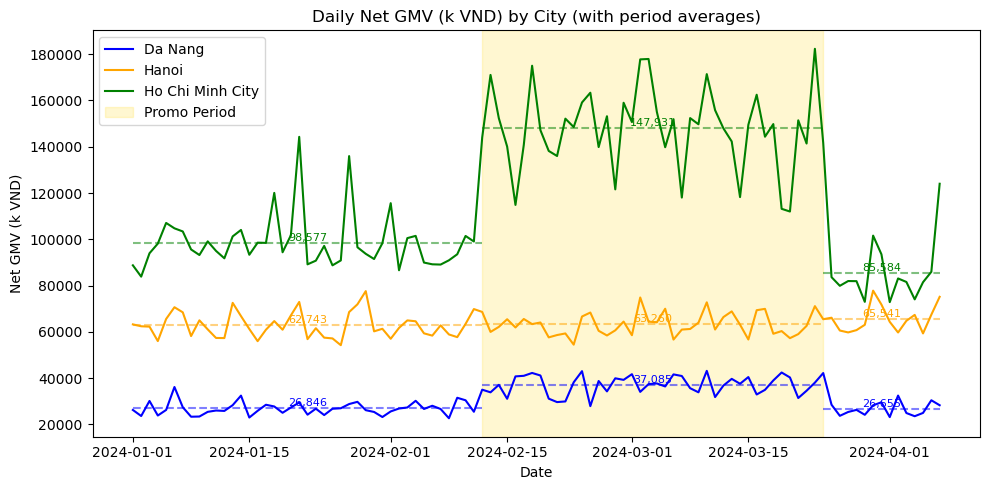

In [8]:
# Chart: Daily net GMV by city with highlighted promo period
plot_df = (
    daily_gmv_summary
    .groupby(['date', 'city'], as_index=False)['net_gmv_k_vnd']
    .sum()
    .sort_values('date')
)
plot_df['date'] = pd.to_datetime(plot_df['date'], errors='coerce')

promo_start = pd.Timestamp('2024-02-12')
promo_end = pd.Timestamp('2024-03-24')
pre_promo_start = plot_df['date'].min()
post_promo_end = plot_df['date'].max()

fig, ax = plt.subplots(figsize=(10, 5))
city_colors = {'Da Nang': 'blue', 'Hanoi': 'orange', 'Ho Chi Minh City': 'green'}

for city, sub in plot_df.groupby('city'):
    sub = sub.copy()
    sub['date'] = pd.to_datetime(sub['date'], errors='coerce')
    ax.plot(sub['date'], sub['net_gmv_k_vnd'], label=city, color=city_colors.get(city))
    
    # Calculate averages for each period
    pre_promo_data = sub[sub['date'] < promo_start]
    during_promo_data = sub[(sub['date'] >= promo_start) & (sub['date'] <= promo_end)]
    post_promo_data = sub[sub['date'] > promo_end]
    
    pre_promo_avg = pre_promo_data['net_gmv_k_vnd'].mean() if len(pre_promo_data) > 0 else None
    during_promo_avg = during_promo_data['net_gmv_k_vnd'].mean() if len(during_promo_data) > 0 else None
    post_promo_avg = post_promo_data['net_gmv_k_vnd'].mean() if len(post_promo_data) > 0 else None
    
    # Draw average lines constrained to their periods
    if pre_promo_avg is not None:
        ax.hlines(pre_promo_avg, pre_promo_start, promo_start, colors=city_colors.get(city), linestyles='--', alpha=0.5, linewidth=1.5)
        mid_date = pre_promo_start + (promo_start - pre_promo_start) / 2
        ax.text(mid_date, pre_promo_avg, f'{pre_promo_avg:,.0f}', fontsize=8, color=city_colors.get(city), va='bottom', ha='center')
    if during_promo_avg is not None:
        ax.hlines(during_promo_avg, promo_start, promo_end, colors=city_colors.get(city), linestyles='--', alpha=0.5, linewidth=1.5)
        mid_date = promo_start + (promo_end - promo_start) / 2
        ax.text(mid_date, during_promo_avg, f'{during_promo_avg:,.0f}', fontsize=8, color=city_colors.get(city), va='bottom', ha='center')
    if post_promo_avg is not None:
        ax.hlines(post_promo_avg, promo_end, post_promo_end, colors=city_colors.get(city), linestyles='--', alpha=0.5, linewidth=1.5)
        mid_date = promo_end + (post_promo_end - promo_end) / 2
        ax.text(mid_date, post_promo_avg, f'{post_promo_avg:,.0f}', fontsize=8, color=city_colors.get(city), va='bottom', ha='center')

ax.axvspan(
    promo_start,
    promo_end,
    color='gold',
    alpha=0.18,
    label='Promo Period'
)

plt.title('Daily Net GMV (k VND) by City (with period averages)')
plt.xlabel('Date')
plt.ylabel('Net GMV (k VND)')
plt.legend()
plt.tight_layout()
plt.show()

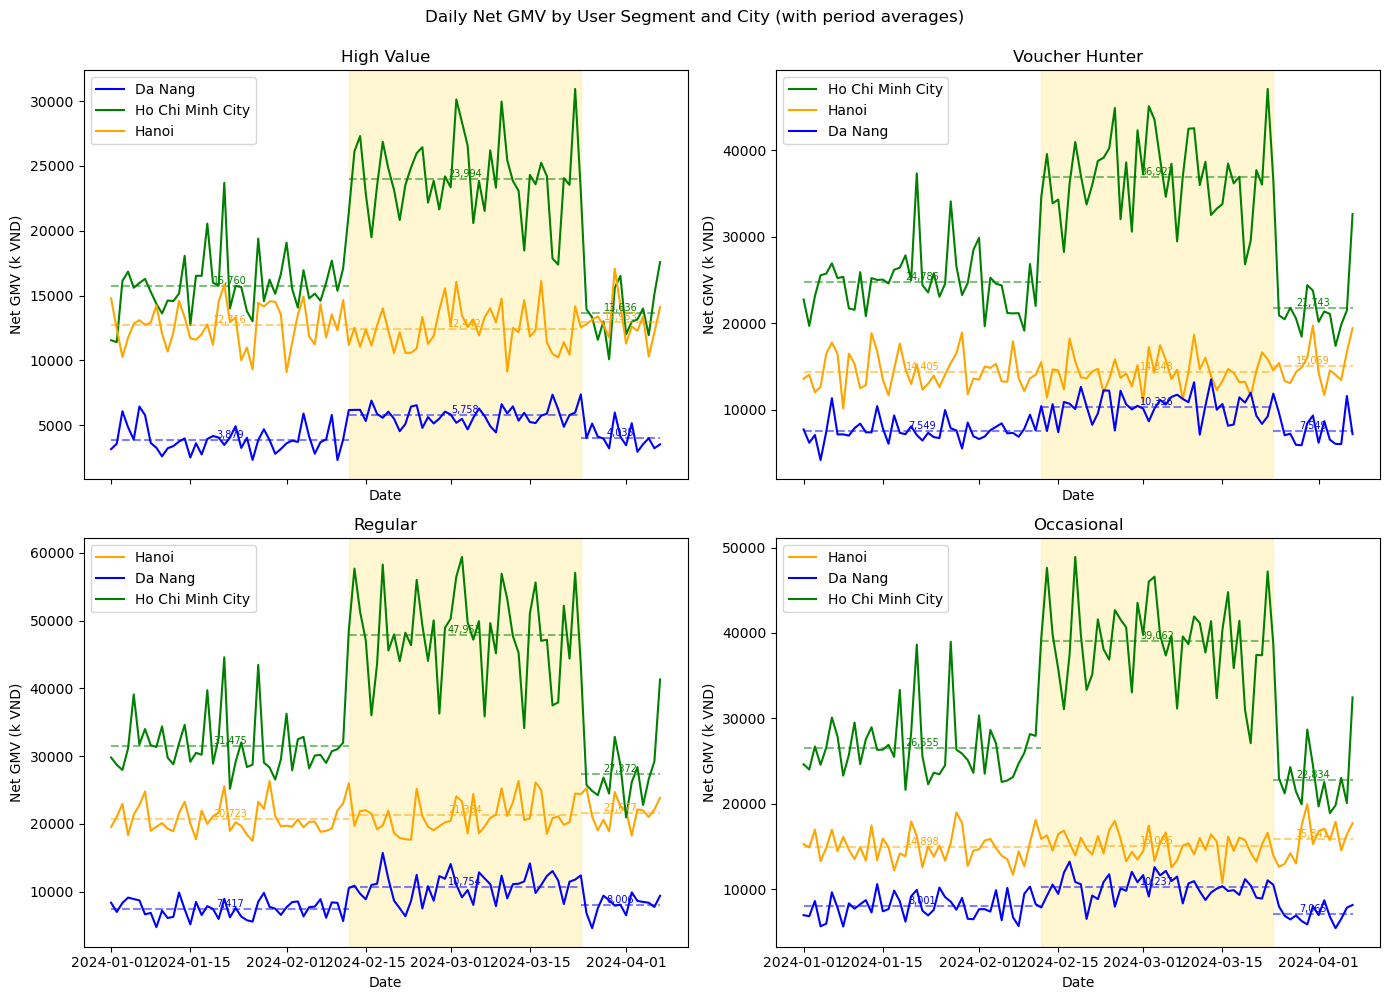

In [9]:
# Chart: daily net GMV by user segment AND city with highlighted promo period
tx_segment = transactions.merge(
    users[['user_id', 'user_segment']],
    on='user_id',
    how='left'
)

segment_city_plot = (
    tx_segment
    .groupby(['date', 'user_segment', 'city'], as_index=False)['net_gmv_k_vnd']
    .sum()
    .sort_values('date')
)
segment_city_plot['date'] = pd.to_datetime(segment_city_plot['date'], errors='coerce')

promo_start = pd.Timestamp('2024-02-12')
promo_end = pd.Timestamp('2024-03-24')
pre_promo_start = segment_city_plot['date'].min()
post_promo_end = segment_city_plot['date'].max()

segments = segment_city_plot['user_segment'].dropna().unique()
fig, axes = plt.subplots(
    nrows=2,
    ncols=2,
    figsize=(14, 10),
    sharex=True,
    sharey=False,
)

axes = axes.flatten()
colors = {'Da Nang': 'blue', 'Hanoi': 'orange', 'Ho Chi Minh City': 'green'}

for ax, segment in zip(axes, segments):
    segment_data = segment_city_plot[
        segment_city_plot['user_segment'] == segment
    ]
    for city in segment_data['city'].unique():
        city_data = segment_data[segment_data['city'] == city].copy()
        city_data['date'] = pd.to_datetime(city_data['date'], errors='coerce')
        ax.plot(
            city_data['date'],
            city_data['net_gmv_k_vnd'],
            label=city,
            color=colors.get(city, 'gray')
        )
        
        # Calculate and draw period averages
        pre_promo_data = city_data[city_data['date'] < promo_start]
        during_promo_data = city_data[(city_data['date'] >= promo_start) & (city_data['date'] <= promo_end)]
        post_promo_data = city_data[city_data['date'] > promo_end]
        
        pre_promo_avg = pre_promo_data['net_gmv_k_vnd'].mean() if len(pre_promo_data) > 0 else None
        during_promo_avg = during_promo_data['net_gmv_k_vnd'].mean() if len(during_promo_data) > 0 else None
        post_promo_avg = post_promo_data['net_gmv_k_vnd'].mean() if len(post_promo_data) > 0 else None
        
        if pre_promo_avg is not None:
            ax.hlines(pre_promo_avg, pre_promo_start, promo_start, colors=colors.get(city), linestyles='--', alpha=0.5, linewidth=1.5)
            mid_date = pre_promo_start + (promo_start - pre_promo_start) / 2
            ax.text(mid_date, pre_promo_avg, f'{pre_promo_avg:,.0f}', fontsize=7, color=colors.get(city), va='bottom', ha='center')
        if during_promo_avg is not None:
            ax.hlines(during_promo_avg, promo_start, promo_end, colors=colors.get(city), linestyles='--', alpha=0.5, linewidth=1.5)
            mid_date = promo_start + (promo_end - promo_start) / 2
            ax.text(mid_date, during_promo_avg, f'{during_promo_avg:,.0f}', fontsize=7, color=colors.get(city), va='bottom', ha='center')
        if post_promo_avg is not None:
            ax.hlines(post_promo_avg, promo_end, post_promo_end, colors=colors.get(city), linestyles='--', alpha=0.5, linewidth=1.5)
            mid_date = promo_end + (post_promo_end - promo_end) / 2
            ax.text(mid_date, post_promo_avg, f'{post_promo_avg:,.0f}', fontsize=7, color=colors.get(city), va='bottom', ha='center')
    
    ax.axvspan(promo_start, promo_end, color='gold', alpha=0.18)
    ax.set_title(str(segment))
    ax.set_xlabel('Date')
    ax.set_ylabel('Net GMV (k VND)')
    ax.legend()

for ax in axes[len(segments):]:
    ax.axis('off')

fig.suptitle('Daily Net GMV by User Segment and City (with period averages)', y=0.995)
fig.tight_layout()
plt.show()

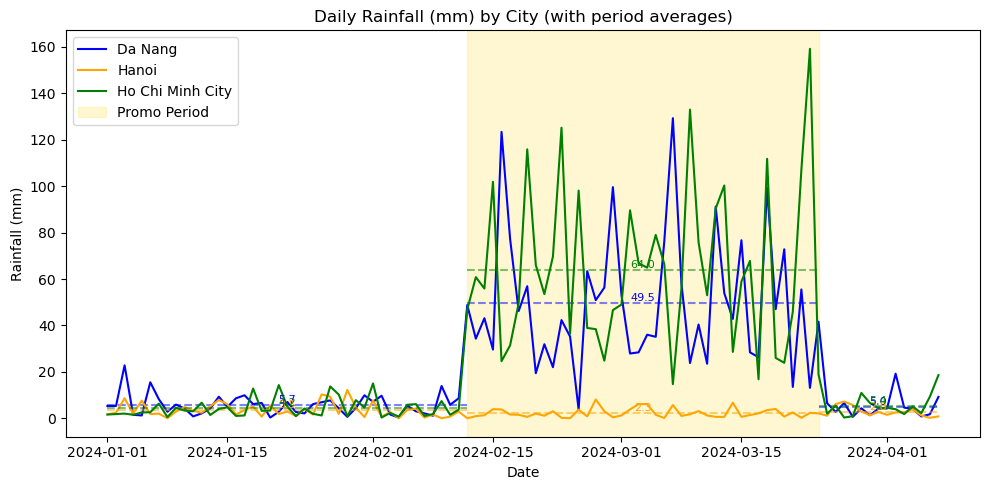

In [10]:
# Chart: daily rainfall by city with highlighted promo period
rain_plot = weather_daily.copy()
rain_plot['date'] = pd.to_datetime(rain_plot['date'], errors='coerce')
rain_plot = rain_plot.sort_values(['city', 'date'])

promo_start = pd.Timestamp('2024-02-12')
promo_end = pd.Timestamp('2024-03-24')
pre_promo_start = rain_plot['date'].min()
post_promo_end = rain_plot['date'].max()

fig, ax = plt.subplots(figsize=(10, 5))
city_colors = {'Da Nang': 'blue', 'Hanoi': 'orange', 'Ho Chi Minh City': 'green'}

for city, sub in rain_plot.groupby('city'):
    ax.plot(sub['date'], sub['rainfall_mm'], label=city, color=city_colors.get(city))
    
    # Calculate and draw period averages
    pre_promo_data = sub[sub['date'] < promo_start]
    during_promo_data = sub[(sub['date'] >= promo_start) & (sub['date'] <= promo_end)]
    post_promo_data = sub[sub['date'] > promo_end]
    
    pre_promo_avg = pre_promo_data['rainfall_mm'].mean() if len(pre_promo_data) > 0 else None
    during_promo_avg = during_promo_data['rainfall_mm'].mean() if len(during_promo_data) > 0 else None
    post_promo_avg = post_promo_data['rainfall_mm'].mean() if len(post_promo_data) > 0 else None
    
    if pre_promo_avg is not None:
        ax.hlines(pre_promo_avg, pre_promo_start, promo_start, colors=city_colors.get(city), linestyles='--', alpha=0.5, linewidth=1.5)
        mid_date = pre_promo_start + (promo_start - pre_promo_start) / 2
        ax.text(mid_date, pre_promo_avg, f'{pre_promo_avg:.1f}', fontsize=8, color=city_colors.get(city), va='bottom', ha='center')
    if during_promo_avg is not None:
        ax.hlines(during_promo_avg, promo_start, promo_end, colors=city_colors.get(city), linestyles='--', alpha=0.5, linewidth=1.5)
        mid_date = promo_start + (promo_end - promo_start) / 2
        ax.text(mid_date, during_promo_avg, f'{during_promo_avg:.1f}', fontsize=8, color=city_colors.get(city), va='bottom', ha='center')
    if post_promo_avg is not None:
        ax.hlines(post_promo_avg, promo_end, post_promo_end, colors=city_colors.get(city), linestyles='--', alpha=0.5, linewidth=1.5)
        mid_date = promo_end + (post_promo_end - promo_end) / 2
        ax.text(mid_date, post_promo_avg, f'{post_promo_avg:.1f}', fontsize=8, color=city_colors.get(city), va='bottom', ha='center')

ax.axvspan(
    promo_start,
    promo_end,
    color='gold',
    alpha=0.18,
    label='Promo Period'
)

plt.title('Daily Rainfall (mm) by City (with period averages)')
plt.xlabel('Date')
plt.ylabel('Rainfall (mm)')
plt.legend()
plt.tight_layout()
plt.show()

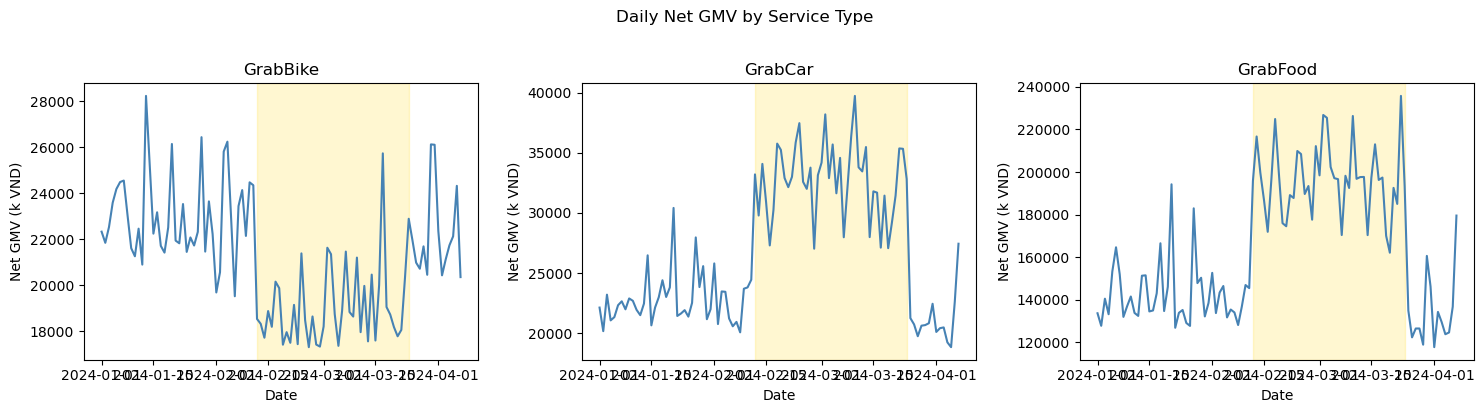

In [11]:
# Chart: daily net GMV by service type with highlighted promo period
service_plot = (
    daily_gmv_summary.copy()
)
service_plot['date'] = pd.to_datetime(service_plot['date'], errors='coerce')
service_plot = (
    service_plot
    .groupby(['date', 'service_type'], as_index=False)['net_gmv_k_vnd']
    .sum()
    .sort_values('date')
)

promo_start = pd.Timestamp('2024-02-12')
promo_end = pd.Timestamp('2024-03-24')

service_order = ['GrabBike', 'GrabCar', 'GrabFood']
fig, axes = plt.subplots(
    nrows=1,
    ncols=3,
    figsize=(15, 4),
    sharex=True,
    sharey=False,
)

for ax, service_type in zip(axes, service_order):
    sub = service_plot[service_plot['service_type'] == service_type]
    ax.plot(sub['date'], sub['net_gmv_k_vnd'], color='steelblue')
    ax.axvspan(promo_start, promo_end, color='gold', alpha=0.18)
    ax.set_title(service_type)
    ax.set_xlabel('Date')
    ax.set_ylabel('Net GMV (k VND)')

fig.suptitle('Daily Net GMV by Service Type', y=1.02)
fig.tight_layout()
plt.show()

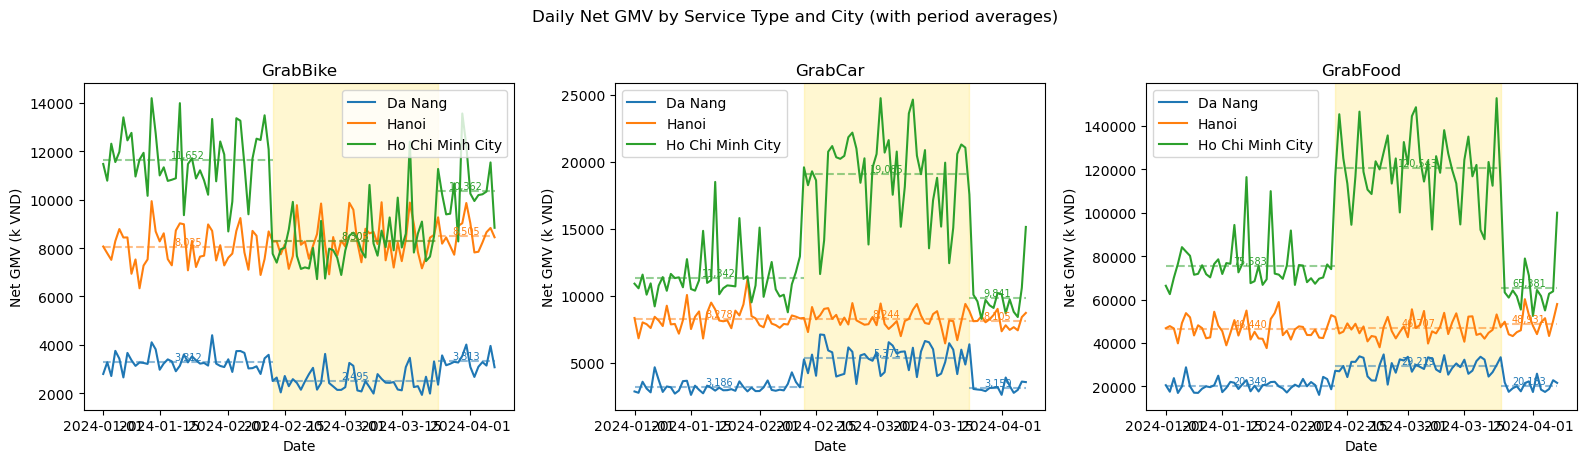

In [12]:
# Chart: daily net GMV by service type, colored by city, with highlighted promo period
service_city_plot = (
    daily_gmv_summary.copy()
)
service_city_plot['date'] = pd.to_datetime(service_city_plot['date'], errors='coerce')
service_city_plot = (
    service_city_plot
    .groupby(['date', 'service_type', 'city'], as_index=False)['net_gmv_k_vnd']
    .sum()
    .sort_values('date')
)

promo_start = pd.Timestamp('2024-02-12')
promo_end = pd.Timestamp('2024-03-24')
pre_promo_start = service_city_plot['date'].min()
post_promo_end = service_city_plot['date'].max()

service_order = ['GrabBike', 'GrabCar', 'GrabFood']
city_colors = {
    'Da Nang': 'tab:blue',
    'Hanoi': 'tab:orange',
    'Ho Chi Minh City': 'tab:green',
}

fig, axes = plt.subplots(
    nrows=1,
    ncols=3,
    figsize=(16, 4.5),
    sharex=True,
    sharey=False,
)

for ax, service_type in zip(axes, service_order):
    service_data = service_city_plot[service_city_plot['service_type'] == service_type]
    for city_name in ['Da Nang', 'Hanoi', 'Ho Chi Minh City']:
        city_data = service_data[service_data['city'] == city_name]
        ax.plot(
            city_data['date'],
            city_data['net_gmv_k_vnd'],
            label=city_name,
            color=city_colors.get(city_name, 'gray')
        )
        
        # Calculate and draw period averages
        pre_promo_data = city_data[city_data['date'] < promo_start]
        during_promo_data = city_data[(city_data['date'] >= promo_start) & (city_data['date'] <= promo_end)]
        post_promo_data = city_data[city_data['date'] > promo_end]
        
        pre_promo_avg = pre_promo_data['net_gmv_k_vnd'].mean() if len(pre_promo_data) > 0 else None
        during_promo_avg = during_promo_data['net_gmv_k_vnd'].mean() if len(during_promo_data) > 0 else None
        post_promo_avg = post_promo_data['net_gmv_k_vnd'].mean() if len(post_promo_data) > 0 else None
        
        if pre_promo_avg is not None:
            ax.hlines(pre_promo_avg, pre_promo_start, promo_start, colors=city_colors.get(city_name), linestyles='--', alpha=0.5, linewidth=1.5)
            mid_date = pre_promo_start + (promo_start - pre_promo_start) / 2
            ax.text(mid_date, pre_promo_avg, f'{pre_promo_avg:,.0f}', fontsize=7, color=city_colors.get(city_name), va='bottom', ha='center')
        if during_promo_avg is not None:
            ax.hlines(during_promo_avg, promo_start, promo_end, colors=city_colors.get(city_name), linestyles='--', alpha=0.5, linewidth=1.5)
            mid_date = promo_start + (promo_end - promo_start) / 2
            ax.text(mid_date, during_promo_avg, f'{during_promo_avg:,.0f}', fontsize=7, color=city_colors.get(city_name), va='bottom', ha='center')
        if post_promo_avg is not None:
            ax.hlines(post_promo_avg, promo_end, post_promo_end, colors=city_colors.get(city_name), linestyles='--', alpha=0.5, linewidth=1.5)
            mid_date = promo_end + (post_promo_end - promo_end) / 2
            ax.text(mid_date, post_promo_avg, f'{post_promo_avg:,.0f}', fontsize=7, color=city_colors.get(city_name), va='bottom', ha='center')
    
    ax.axvspan(promo_start, promo_end, color='gold', alpha=0.18)
    ax.set_title(service_type)
    ax.set_xlabel('Date')
    ax.set_ylabel('Net GMV (k VND)')
    ax.legend()

fig.suptitle('Daily Net GMV by Service Type and City (with period averages)', y=1.02)
fig.tight_layout()
plt.show()

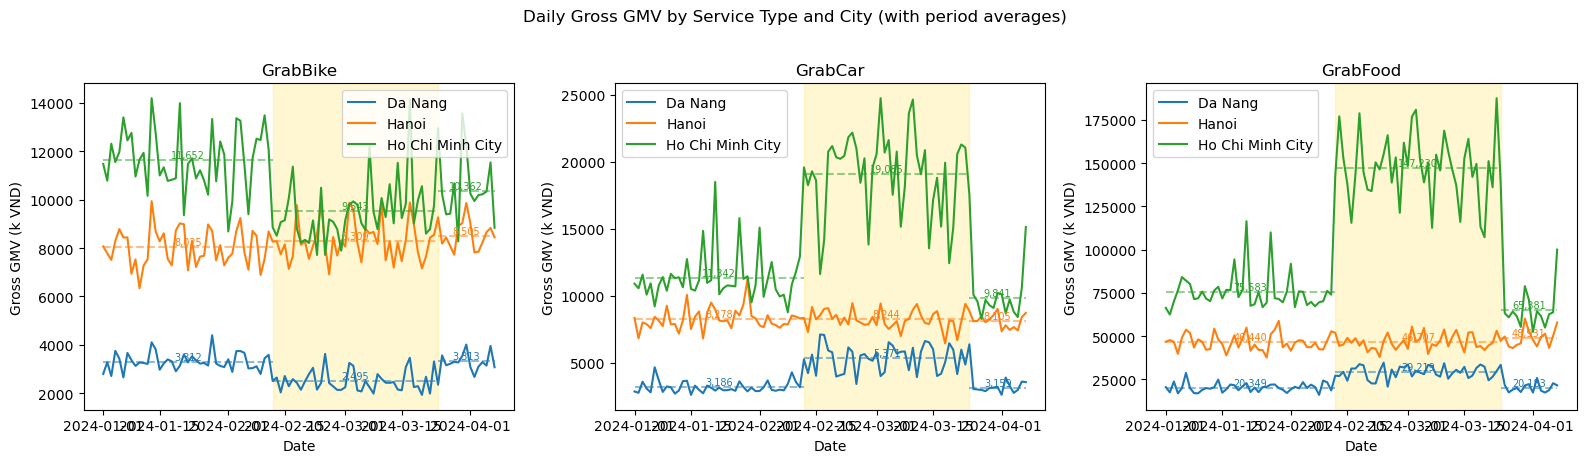

In [13]:
# Chart: daily gross GMV by service type, colored by city, with highlighted promo period
service_city_plot = (
    daily_gmv_summary.copy()
)
service_city_plot['date'] = pd.to_datetime(service_city_plot['date'], errors='coerce')
service_city_plot = (
    service_city_plot
    .groupby(['date', 'service_type', 'city'], as_index=False)['gross_gmv_k_vnd']
    .sum()
    .sort_values('date')
)

promo_start = pd.Timestamp('2024-02-12')
promo_end = pd.Timestamp('2024-03-24')
pre_promo_start = service_city_plot['date'].min()
post_promo_end = service_city_plot['date'].max()

service_order = ['GrabBike', 'GrabCar', 'GrabFood']
city_colors = {
    'Da Nang': 'tab:blue',
    'Hanoi': 'tab:orange',
    'Ho Chi Minh City': 'tab:green',
}

fig, axes = plt.subplots(
    nrows=1,
    ncols=3,
    figsize=(16, 4.5),
    sharex=True,
    sharey=False,
)

for ax, service_type in zip(axes, service_order):
    service_data = service_city_plot[service_city_plot['service_type'] == service_type]
    for city_name in ['Da Nang', 'Hanoi', 'Ho Chi Minh City']:
        city_data = service_data[service_data['city'] == city_name]
        ax.plot(
            city_data['date'],
            city_data['gross_gmv_k_vnd'],
            label=city_name,
            color=city_colors.get(city_name, 'gray')
        )
        
        # Calculate and draw period averages
        pre_promo_data = city_data[city_data['date'] < promo_start]
        during_promo_data = city_data[(city_data['date'] >= promo_start) & (city_data['date'] <= promo_end)]
        post_promo_data = city_data[city_data['date'] > promo_end]
        
        pre_promo_avg = pre_promo_data['gross_gmv_k_vnd'].mean() if len(pre_promo_data) > 0 else None
        during_promo_avg = during_promo_data['gross_gmv_k_vnd'].mean() if len(during_promo_data) > 0 else None
        post_promo_avg = post_promo_data['gross_gmv_k_vnd'].mean() if len(post_promo_data) > 0 else None
        
        if pre_promo_avg is not None:
            ax.hlines(pre_promo_avg, pre_promo_start, promo_start, colors=city_colors.get(city_name), linestyles='--', alpha=0.5, linewidth=1.5)
            mid_date = pre_promo_start + (promo_start - pre_promo_start) / 2
            ax.text(mid_date, pre_promo_avg, f'{pre_promo_avg:,.0f}', fontsize=7, color=city_colors.get(city_name), va='bottom', ha='center')
        if during_promo_avg is not None:
            ax.hlines(during_promo_avg, promo_start, promo_end, colors=city_colors.get(city_name), linestyles='--', alpha=0.5, linewidth=1.5)
            mid_date = promo_start + (promo_end - promo_start) / 2
            ax.text(mid_date, during_promo_avg, f'{during_promo_avg:,.0f}', fontsize=7, color=city_colors.get(city_name), va='bottom', ha='center')
        if post_promo_avg is not None:
            ax.hlines(post_promo_avg, promo_end, post_promo_end, colors=city_colors.get(city_name), linestyles='--', alpha=0.5, linewidth=1.5)
            mid_date = promo_end + (post_promo_end - promo_end) / 2
            ax.text(mid_date, post_promo_avg, f'{post_promo_avg:,.0f}', fontsize=7, color=city_colors.get(city_name), va='bottom', ha='center')
    
    ax.axvspan(promo_start, promo_end, color='gold', alpha=0.18)
    ax.set_title(service_type)
    ax.set_xlabel('Date')
    ax.set_ylabel('Gross GMV (k VND)')
    ax.legend()

fig.suptitle('Daily Gross GMV by Service Type and City (with period averages)', y=1.02)
fig.tight_layout()
plt.show()

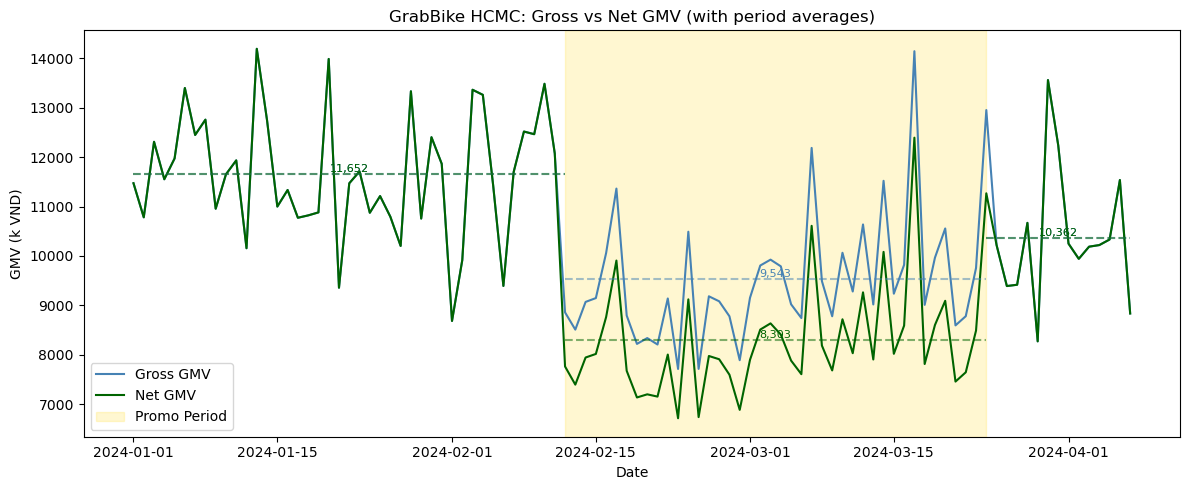

In [14]:
# Chart: GrabBike HCMC - Gross vs Net GMV with highlighted promo period
grabike_hcmc = (
    daily_gmv_summary.copy()
)
grabike_hcmc['date'] = pd.to_datetime(grabike_hcmc['date'], errors='coerce')
grabike_hcmc = (
    grabike_hcmc[
        (grabike_hcmc['service_type'] == 'GrabBike') &
        (grabike_hcmc['city'] == 'Ho Chi Minh City')
    ]
    .groupby(['date'], as_index=False)[['gross_gmv_k_vnd', 'net_gmv_k_vnd']]
    .sum()
    .sort_values('date')
)

promo_start = pd.Timestamp('2024-02-12')
promo_end = pd.Timestamp('2024-03-24')
pre_promo_start = grabike_hcmc['date'].min()
post_promo_end = grabike_hcmc['date'].max()

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(grabike_hcmc['date'], grabike_hcmc['gross_gmv_k_vnd'], label='Gross GMV', color='steelblue')
ax.plot(grabike_hcmc['date'], grabike_hcmc['net_gmv_k_vnd'], label='Net GMV', color='darkgreen')

# Calculate and draw period averages for both metrics
for metric, color in [('gross_gmv_k_vnd', 'steelblue'), ('net_gmv_k_vnd', 'darkgreen')]:
    pre_promo_data = grabike_hcmc[grabike_hcmc['date'] < promo_start]
    during_promo_data = grabike_hcmc[(grabike_hcmc['date'] >= promo_start) & (grabike_hcmc['date'] <= promo_end)]
    post_promo_data = grabike_hcmc[grabike_hcmc['date'] > promo_end]
    
    pre_promo_avg = pre_promo_data[metric].mean() if len(pre_promo_data) > 0 else None
    during_promo_avg = during_promo_data[metric].mean() if len(during_promo_data) > 0 else None
    post_promo_avg = post_promo_data[metric].mean() if len(post_promo_data) > 0 else None
    
    if pre_promo_avg is not None:
        ax.hlines(pre_promo_avg, pre_promo_start, promo_start, colors=color, linestyles='--', alpha=0.5, linewidth=1.5)
        mid_date = pre_promo_start + (promo_start - pre_promo_start) / 2
        ax.text(mid_date, pre_promo_avg, f'{pre_promo_avg:,.0f}', fontsize=8, color=color, va='bottom', ha='center')
    if during_promo_avg is not None:
        ax.hlines(during_promo_avg, promo_start, promo_end, colors=color, linestyles='--', alpha=0.5, linewidth=1.5)
        mid_date = promo_start + (promo_end - promo_start) / 2
        ax.text(mid_date, during_promo_avg, f'{during_promo_avg:,.0f}', fontsize=8, color=color, va='bottom', ha='center')
    if post_promo_avg is not None:
        ax.hlines(post_promo_avg, promo_end, post_promo_end, colors=color, linestyles='--', alpha=0.5, linewidth=1.5)
        mid_date = promo_end + (post_promo_end - promo_end) / 2
        ax.text(mid_date, post_promo_avg, f'{post_promo_avg:,.0f}', fontsize=8, color=color, va='bottom', ha='center')

ax.axvspan(
    promo_start,
    promo_end,
    color='gold',
    alpha=0.18,
    label='Promo Period'
)

plt.title('GrabBike HCMC: Gross vs Net GMV (with period averages)')
plt.xlabel('Date')
plt.ylabel('GMV (k VND)')
plt.legend()
plt.tight_layout()
plt.show()

## Naive promotion effect for GrabFood (HCMC vs Da Nang)

This follows the naive approach in the writeup: use Da Nang GrabFood to estimate the rain effect, then apply it to HCMC to form a counterfactual during promo.

In [8]:
# Naive promo effect for GrabFood using Da Nang as rain proxy
promo_start = pd.Timestamp('2024-02-12')
promo_end = pd.Timestamp('2024-03-24')

service = 'GrabFood'
cities = ['Da Nang', 'Ho Chi Minh City']

gf_daily = (
    daily_gmv_summary
    .loc[daily_gmv_summary['service_type'] == service]
    .loc[daily_gmv_summary['city'].isin(cities)]
    .copy()
    .assign(date=lambda df: pd.to_datetime(df['date'], errors='coerce'))
    .groupby(['date', 'city'], as_index=False)['gross_gmv_k_vnd']
    .sum()
    .sort_values(['city', 'date'])
)

def period_avg(df, city, start=None, end=None):
    sub = df[df['city'] == city]
    if start is not None:
        sub = sub[sub['date'] >= start]
    if end is not None:
        sub = sub[sub['date'] <= end]
    return sub['gross_gmv_k_vnd'].mean()

# Da Nang averages to estimate rain effect
dn_pre = period_avg(gf_daily, 'Da Nang', end=promo_start - pd.Timedelta(days=1))
dn_during = period_avg(gf_daily, 'Da Nang', start=promo_start, end=promo_end)

if dn_pre is None or pd.isna(dn_pre) or dn_pre == 0:
    raise ValueError('Da Nang pre-promo average is missing or zero; cannot compute x_rain.')

x_rain = (dn_during - dn_pre) / dn_pre

# HCMC counterfactual and promo effect
hcmc_pre = period_avg(gf_daily, 'Ho Chi Minh City', end=promo_start - pd.Timedelta(days=1))
hcmc_during = period_avg(gf_daily, 'Ho Chi Minh City', start=promo_start, end=promo_end)
hcmc_counterfactual = hcmc_pre * (1 + x_rain)
promo_effect = (hcmc_during - hcmc_counterfactual) / hcmc_counterfactual

result = pd.DataFrame([
    {
        'service_type': service,
        'metric': 'gross_gmv_k_vnd',
        'dn_pre_avg': dn_pre,
        'dn_during_avg': dn_during,
        'x_rain': x_rain,
        'hcmc_pre_avg': hcmc_pre,
        'hcmc_during_avg': hcmc_during,
        'hcmc_counterfactual': hcmc_counterfactual,
        'promotion_effect': promo_effect,
    }
])

result

,service_type,metric,dn_pre_avg,dn_during_avg,x_rain,hcmc_pre_avg,hcmc_during_avg,hcmc_counterfactual,promotion_effect
0,GrabFood,gross_gmv_k_vnd,20348.631429,29219.203095,0.43593,75583.000714,147230.465952,108531.871353,0.356564


## Naive promotion effect for GrabBike (HCMC vs Da Nang)

Same calculation as GrabFood, using GrabBike net GMV.

In [9]:
# Naive promo effect for GrabBike using Da Nang as rain proxy
promo_start = pd.Timestamp('2024-02-12')
promo_end = pd.Timestamp('2024-03-24')

service = 'GrabBike'
cities = ['Da Nang', 'Ho Chi Minh City']

gb_daily = (
    daily_gmv_summary
    .loc[daily_gmv_summary['service_type'] == service]
    .loc[daily_gmv_summary['city'].isin(cities)]
    .copy()
    .assign(date=lambda df: pd.to_datetime(df['date'], errors='coerce'))
    .groupby(['date', 'city'], as_index=False)['gross_gmv_k_vnd']
    .sum()
    .sort_values(['city', 'date'])
)

def period_avg(df, city, start=None, end=None):
    sub = df[df['city'] == city]
    if start is not None:
        sub = sub[sub['date'] >= start]
    if end is not None:
        sub = sub[sub['date'] <= end]
    return sub['gross_gmv_k_vnd'].mean()

# Da Nang averages to estimate rain effect
dn_pre = period_avg(gb_daily, 'Da Nang', end=promo_start - pd.Timedelta(days=1))
dn_during = period_avg(gb_daily, 'Da Nang', start=promo_start, end=promo_end)

if dn_pre is None or pd.isna(dn_pre) or dn_pre == 0:
    raise ValueError('Da Nang pre-promo average is missing or zero; cannot compute x_rain.')

x_rain = (dn_during - dn_pre) / dn_pre

# HCMC counterfactual and promo effect
hcmc_pre = period_avg(gb_daily, 'Ho Chi Minh City', end=promo_start - pd.Timedelta(days=1))
hcmc_during = period_avg(gb_daily, 'Ho Chi Minh City', start=promo_start, end=promo_end)
hcmc_counterfactual = hcmc_pre * (1 + x_rain)
promo_effect = (hcmc_during - hcmc_counterfactual) / hcmc_counterfactual

result_grabbike = pd.DataFrame([
    {
        'service_type': service,
        'metric': 'gross_gmv_k_vnd',
        'dn_pre_avg': dn_pre,
        'dn_during_avg': dn_during,
        'x_rain': x_rain,
        'hcmc_pre_avg': hcmc_pre,
        'hcmc_during_avg': hcmc_during,
        'hcmc_counterfactual': hcmc_counterfactual,
        'promotion_effect': promo_effect,
    }
])

result_grabbike

,service_type,metric,dn_pre_avg,dn_during_avg,x_rain,hcmc_pre_avg,hcmc_during_avg,hcmc_counterfactual,promotion_effect
0,GrabBike,gross_gmv_k_vnd,3311.561667,2495.460238,-0.24644,11651.952381,9543.002143,8780.444633,0.086847


## Combined naive promotion effects

This combines the GrabFood and GrabBike results above into one table.

In [10]:
# Combine GrabFood + GrabBike naive results
combined_naive = pd.concat([result, result_grabbike], ignore_index=True)
combined_naive = combined_naive[
    [
        'service_type',
        'metric',
        'dn_pre_avg',
        'dn_during_avg',
        'x_rain',
        'hcmc_pre_avg',
        'hcmc_during_avg',
        'hcmc_counterfactual',
        'promotion_effect',
    ]
]
combined_naive = combined_naive.sort_values('service_type')

combined_naive.T

,1,0
service_type,GrabBike,GrabFood
metric,gross_gmv_k_vnd,gross_gmv_k_vnd
dn_pre_avg,3311.561667,20348.631429
dn_during_avg,2495.460238,29219.203095
x_rain,-0.24644,0.43593
hcmc_pre_avg,11651.952381,75583.000714
hcmc_during_avg,9543.002143,147230.465952
hcmc_counterfactual,8780.444633,108531.871353
promotion_effect,0.086847,0.356564


## Bootstrap CI for naive promotion effect

Bootstrap resamples days within each city/period to estimate a confidence interval for the naive promotion effect.

In [11]:
import numpy as np

def bootstrap_naive_ci(daily_df, service_type, n_boot=2000, seed=42):
    rng = np.random.default_rng(seed)
    df = daily_df[daily_df['service_type'] == service_type].copy()
    df['date'] = pd.to_datetime(df['date'], errors='coerce')
    df = df[df['city'].isin(['Da Nang', 'Ho Chi Minh City'])]
    df = df.groupby(['date', 'city'], as_index=False)['gross_gmv_k_vnd'].sum()

    def split_period(sub):
        pre = sub[sub['date'] < promo_start]['gross_gmv_k_vnd'].to_numpy()
        during = sub[(sub['date'] >= promo_start) & (sub['date'] <= promo_end)]['gross_gmv_k_vnd'].to_numpy()
        return pre, during

    dn_pre, dn_during = split_period(df[df['city'] == 'Da Nang'])
    hcmc_pre, hcmc_during = split_period(df[df['city'] == 'Ho Chi Minh City'])

    if len(dn_pre) == 0 or len(dn_during) == 0 or len(hcmc_pre) == 0 or len(hcmc_during) == 0:
        raise ValueError('Not enough days in one of the periods to bootstrap.')

    effects = np.empty(n_boot)
    for i in range(n_boot):
        dn_pre_b = rng.choice(dn_pre, size=len(dn_pre), replace=True).mean()
        dn_during_b = rng.choice(dn_during, size=len(dn_during), replace=True).mean()
        x_rain_b = (dn_during_b - dn_pre_b) / dn_pre_b

        hcmc_pre_b = rng.choice(hcmc_pre, size=len(hcmc_pre), replace=True).mean()
        hcmc_during_b = rng.choice(hcmc_during, size=len(hcmc_during), replace=True).mean()
        hcmc_counter_b = hcmc_pre_b * (1 + x_rain_b)
        effects[i] = (hcmc_during_b - hcmc_counter_b) / hcmc_counter_b

    ci_low, ci_high = np.percentile(effects, [2.5, 97.5])
    return effects.mean(), ci_low, ci_high

ci_rows = []
for service_type in ['GrabFood', 'GrabBike']:
    mean_eff, ci_low, ci_high = bootstrap_naive_ci(daily_gmv_summary, service_type)
    ci_rows.append({
        'service_type': service_type,
        'bootstrap_mean_effect': mean_eff,
        'ci_95_low': ci_low,
        'ci_95_high': ci_high,
        'n_boot': 2000,
    })

bootstrap_ci = pd.DataFrame(ci_rows)
bootstrap_ci

,service_type,bootstrap_mean_effect,ci_95_low,ci_95_high,n_boot
0,GrabFood,0.358209,0.254718,0.469131,2000
1,GrabBike,0.088104,0.001288,0.180620,2000
